In [3]:
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
from ibl_info.prepare_data_pid import (
    cleaned_regions_flags,
    get_new_cinc_intervals,
    get_window,
    prepare_ephys_data,
)
from ibl_info.utils import (
    alternate_discretize,
    compute_mutual_information,
    compute_pid,
    compute_trivariate_mi,
    FIRING_RATE,
    discretize,
    equipopulated_binning,
)
import os
import concurrent.futures
import functools
import random
from glob import glob
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
# the plan is to use cells that pass the significance tests
# these results are crazy prohibitive though
# the pid results should come thick and fast

In [6]:
one = ONE()
session_id = "004d8fd5-41e7-4f1b-a45b-0d4ad76fe446"

In [58]:
unit_df = bwm_units(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv


(S3) /Users/dkundu/Downloads/ONE/openalyx.internationalbrainlab.org/bwm_tables/trials.pqt: 100%|██████████| 24.2M/24.2M [00:12<00:00, 1.89MB/s]
(S3) /Users/dkundu/Downloads/ONE/openalyx.internationalbrainlab.org/bwm_tables/clusters.pqt: 100%|██████████| 91.6M/91.6M [00:09<00:00, 9.42MB/s]


d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [60]:
unit_df.to_csv("bwm_units.csv", index=False)

In [7]:
epoch = "stim"
pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
    spikes, clusters = merge_probes(
        [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
    )
else:
    spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
intervals, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(
    trials, epoch
)

In [6]:
epoch = "stim"
important_regions = [
    "VISp",
    "MOs",
    "SSp-ul",
    "ACAd",
    "PL",
    "CP",
    "VPM",
    "MG",
    "LGd",
    "ZI",
    "SNr",
    "MRN",
    "SCm",
    "PAG",
    "APN",
    "RN",
    "PPN",
    "PRNc",
    "PRNr",
    "GRN",
    "IRN",
    "PGRN",
    "CUL4 5",
    "SIM",
    "IP",
]

In [29]:
binned_spikes, actual_regions, n_units, cluster_uuids_list = prepare_ephys_data(
    spikes, clusters, intervals, ["IP"], minimum_units=3
)

Region found IP, 14


In [43]:
filename = f"../data/processed/significance_results_{session_id}.csv"
df = pd.read_csv(filename)
ccids_significant = df[df["p_value"] <= 0.05]["QC_cluster_id"].values

In [45]:
ccids_significant

array([ 270,  380,  733,  762,  764,  791,  827,  876,  944,  947,  999,
       1032, 1074])

In [50]:
mask = np.isin(np.asarray(cluster_uuids_list[0]), ccids_significant)

In [54]:
mask = np.ones(len(cluster_uuids_list[0]), dtype=bool)

In [55]:
impn = binned_spikes[0][:, mask]

In [56]:
impn.shape

(692, 14)

In [1]:
# load and check
# then we can run the decomposition
# skip if leftover neurons < 2

In [2]:
file = "../data/processed/single_cell_test_passed_stim.pkl"

In [3]:
with open(file, "rb") as f:
    data = pkl.load(f)

In [4]:
region_names = []
significant_neurons = []
for k in data.keys():
    region = data[k]
    region_names.append(k)
    neurons = []
    for eid in region.keys():
        neurons.append(region[eid])
    significant_neurons.append(neurons)

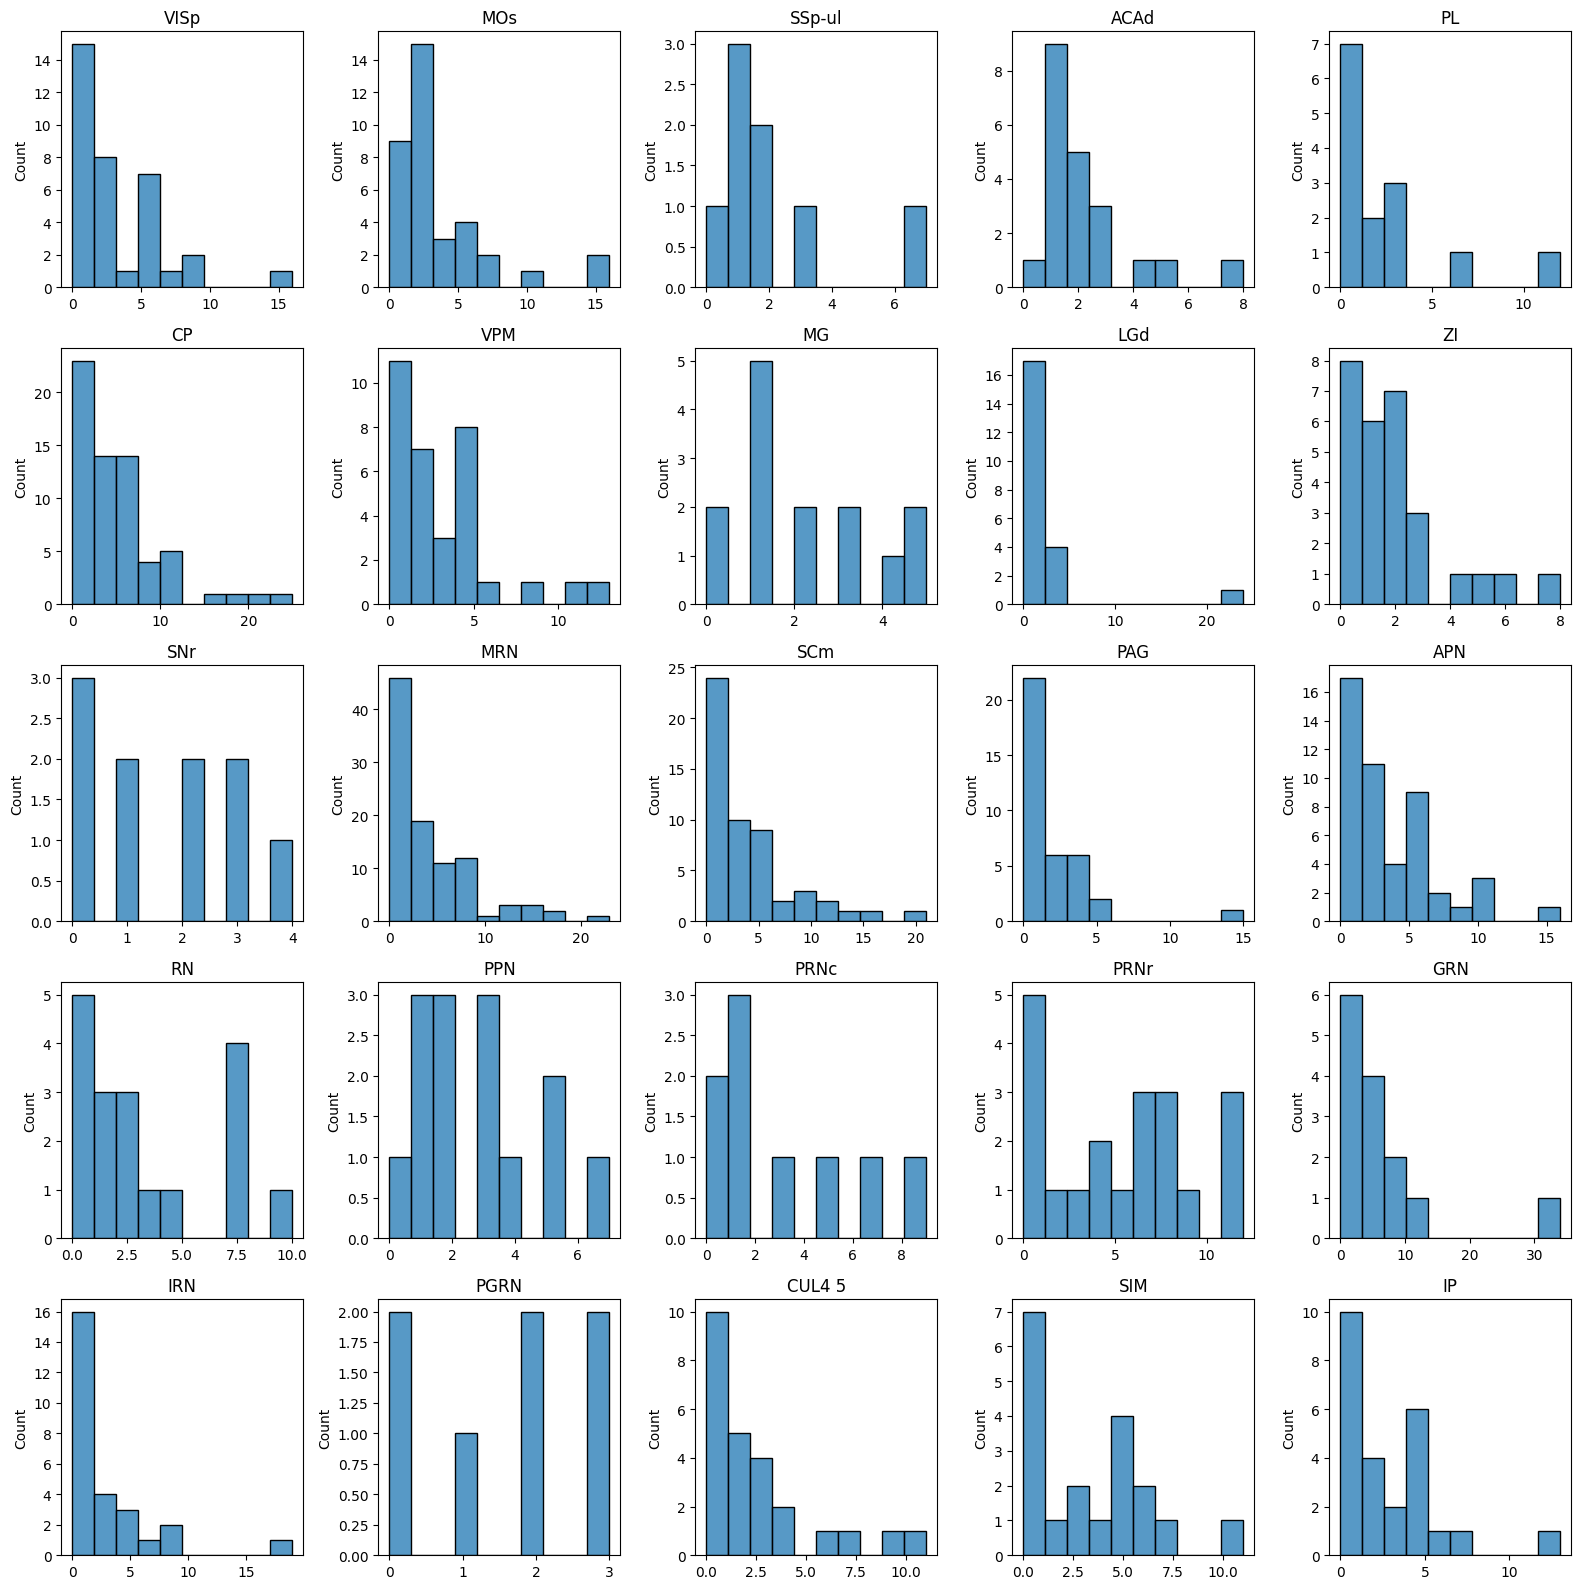

In [11]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(16, 16))

for idx, ax in enumerate(axes.flatten()):
    nneurons = np.asarray(significant_neurons[idx])
    # mask = (nneurons != 0) & (nneurons != 1)
    filtered_arr = nneurons  # [mask]
    sns.histplot(filtered_arr, ax=ax, bins=10)
    ax.set_title(region_names[idx])
plt.tight_layout()

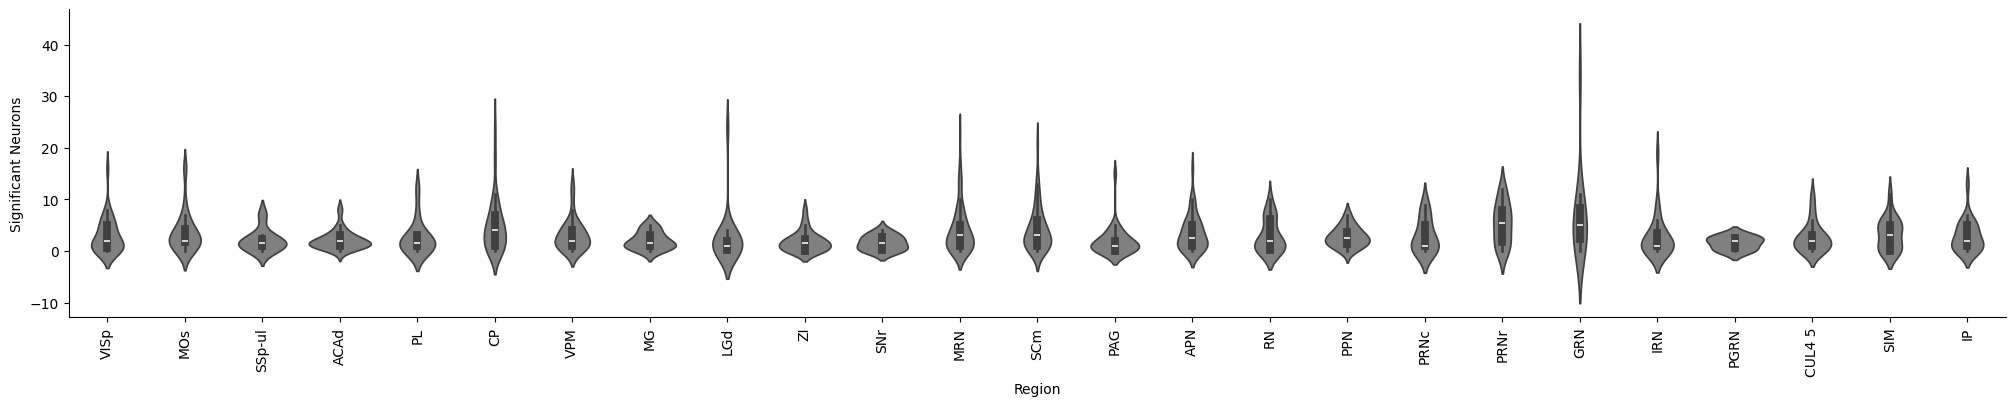

In [29]:
fig, ax = plt.subplots(figsize=(25, 4))
sns.violinplot(significant_neurons, color="grey", ax=ax)
ax.set_xticks(np.arange(len(region_names)), region_names, rotation=90)
ax.set_xlabel("Region")
ax.set_ylabel("Significant Neurons")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

In [8]:
one = ONE()
X = bwm_units(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [13]:
d

,region,euclidean_latency,euclidean_effect,glm_effect,mannwhitney_effect,decoding_effect,decoding_significant,mannwhitney_significant,euclidean_significant
0,ACAd,-0.025532,0.329576,-3.163099,0.057034,0.113388,1,1,1
1,ACAv,-0.100000,0.217380,-3.324079,0.000000,0.044552,1,0,1
2,ACB,-0.012766,0.179645,-3.492325,0.012821,0.030974,1,0,1
3,AId,-0.076596,0.126160,-3.477468,0.029940,0.050150,1,1,0
4,AIp,-0.074468,0.187427,-3.377583,0.025974,0.079576,1,1,1
...,...,...,...,...,...,...,...,...,...
135,VISrl,-0.065957,0.119966,-3.105570,0.071429,0.102140,1,1,1
136,VM,-0.057447,0.222139,-3.183571,0.068966,0.141684,1,1,1
137,VPL,-0.036170,0.219782,-3.272142,0.053922,0.136658,1,1,1
138,VPM,-0.010638,0.149554,-3.339175,0.020186,0.057790,1,1,1


### BWM single cell results


In [1]:
import pandas as pd
import pickle as pkl
import numpy as np

In [2]:
df_choice = pd.read_csv("../data/external/bwm_single_cell_choice_2024_10_21.csv")
df_stim = pd.read_csv("../data/external/bwm_single_cell_stim_2024_10_21.csv")

In [49]:
df_choice.columns

Index(['session_index', 'pid', 'eid', 'probe_name', 'cluster_id', 'beryl_id',
       'atlas_id', 'p_value_choice', 'MW_p_value_choice'],
      dtype='object')

In [17]:
compact_df_stim = df_stim[df_stim.eid == session_id]

In [25]:
compact_df_stim

,session_index,pid,eid,probe_name,cluster_id,beryl_id,atlas_id,p_value_stim,MW_p_value_stim
30628,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,18,437,437,0.170776,0.190603
30629,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,23,437,437,0.254082,0.687937
30630,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,52,437,437,0.427358,0.195268
30631,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,81,437,437,0.120293,0.378207
30632,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,108,437,437,0.813729,0.029490
...,...,...,...,...,...,...,...,...,...
30739,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,1062,984,984,0.812063,0.723259
30740,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,1074,984,984,0.011996,0.188770
30741,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,1089,984,984,0.425858,0.486504
30742,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,1185,217,217,0.567811,0.373709


In [31]:
cluster_uuids_list

[[741, 745, 746, 747, 752, 753, 754, 755, 762, 763, 764, 765, 772, 780]]

In [36]:
truncated_df = compact_df_stim[compact_df_stim["cluster_id"].isin(cluster_uuids_list[0])]

In [48]:
truncated_df.iloc[0].p_value_stim

np.float64(0.4948350549816728)

In [51]:
from ibl_info.prepare_data_pid import return_significant_cells

In [59]:
mask = return_significant_cells(session_id, "choice", cluster_uuids_list)

In [61]:
mask

array([False, False, False,  True, False, False, False, False,  True,
       False, False, False, False, False])

,session_index,pid,eid,probe_name,cluster_id,beryl_id,atlas_id,p_value_choice,MW_p_value_choice
30699,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,741,91,91,0.221093,0.314229
30700,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,745,91,91,0.452016,0.779074
30701,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,746,91,91,0.104299,0.594469
30702,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,747,91,91,0.036321,0.525825
30703,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,752,91,91,0.285238,0.622126
30704,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,753,91,91,0.524492,0.742586
30705,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,754,91,91,0.734255,0.542652
30706,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,755,91,91,0.484339,0.369377
30707,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,762,91,91,0.024159,0.147284
30708,317,d65ab768-bd77-4719-acb9-677abca4e9d8,004d8fd5-41e7-4f1b-a45b-0d4ad76fe446,probe00,763,91,91,0.507164,0.279907
